## MCP Cleint Architecture and Fundamentals

### Objectivds
- 3 layer architecture of MCP
- Unserstand the fundamentals of MCP client communications
    - lifecycle phases
    - capacity negotiation
- Describe the MCP server primitives, and the basics of STDIO transport
- Explain how MCP support a multi-sever client architecture
- Describe the difference between TypeScirpt and Python SDKs for MCP
- Test and validate MCP clients

### 3 layer archtecture
- Host: manages clients
- Client: connect with exactly one server
    - one client connect with exactly one server
- Sever
    - Prmitives: (resources, tools, prompts)

### Json-RPC 2.0
- 3 message types
    - Requests
        - expect a `result` or an `error`
    - Reponses
    - Notification
        - no id or no response
- 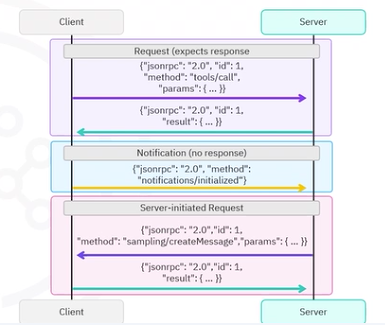
- bidirectional communication
- All messages are JSON objects over STDIO or Stramable HTTP

### MCP client connection: Three phases
- Phase 1: initialization
    - client sends initialize request with protocol version and client capabilites
    - sever responds with its capabilites  and protocol version
    - Client **MUST** send an initialized notification to complete the handshake
    - 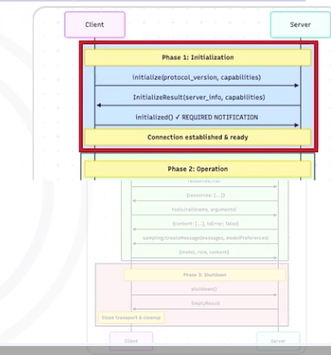

- Phase 2: Operation
    - Client discover capabilites using `list_tools`, `list_resources` and `list_prompts`
    - Cleit invokes tools, read resources, and get prompts
    - Server can request sampling

- Phase 3: shutdown
    - Client sends shutdown request
    - Server responds
    - Connection closes with cleanup process

### Capability negotiation
- 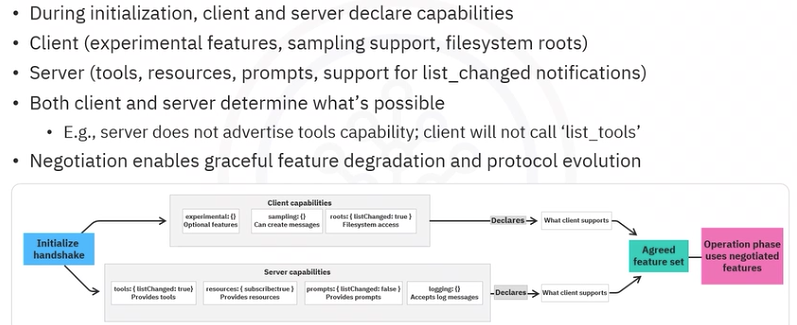

### MCP primitives: Tools, resources, and prompts
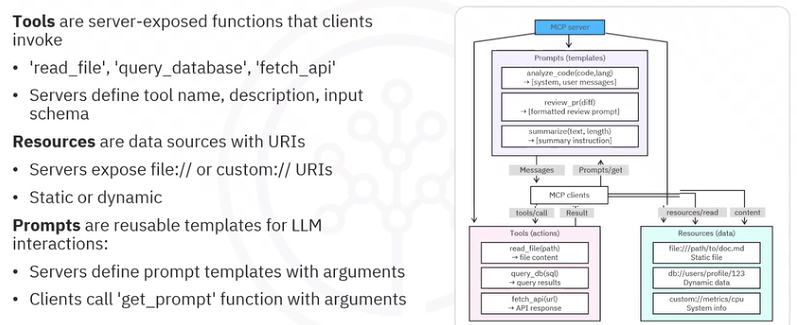

### STDIO trasport
- simplest trasport mechanism
    - local development, commandline tools
- client spawns a server process
- communicate through STDIO
- Messages are newline delimited JSON
- `server` write ouputs to `stdout`
- **error** logs to `stderr`
- this is a **Process-based** trasport: when the client termnates the sever process ends
- Secure for local-onlz scenario: no network exposure, no authentication needed
- Default trasport for local MCP servers (filesystem, git, database connectors)

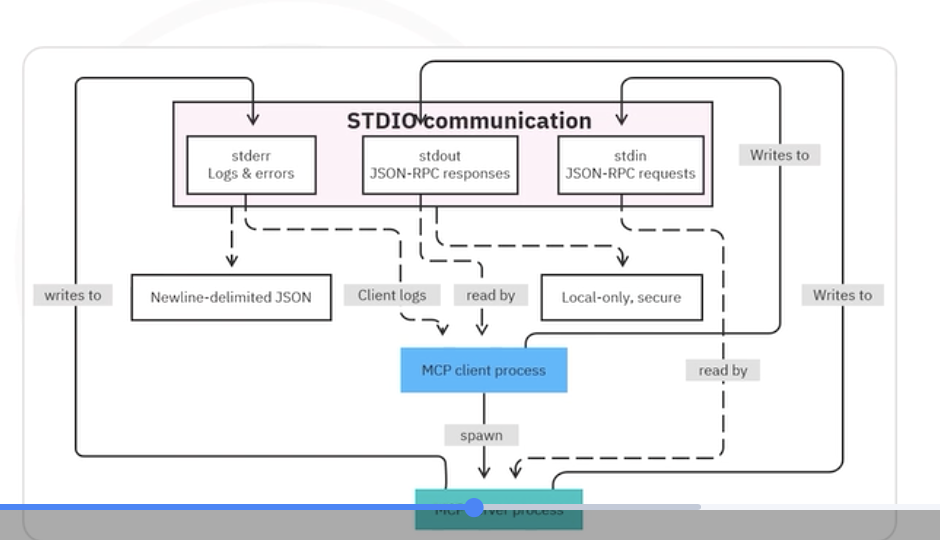

### Multi-server client architecture
- Production systems, client connect to multiple servers
- the host create one client for each sever. 
- Each client independetlz manages its own lifecycle
    - initialization, capability negotiation, and opeation
- Host aggregates capabilites accross different servers
- Host combines tool lists, resoucresm URIs, and available prompts
- When the LLM needs to call a tool, the host routes the request to the correct client based on tool name

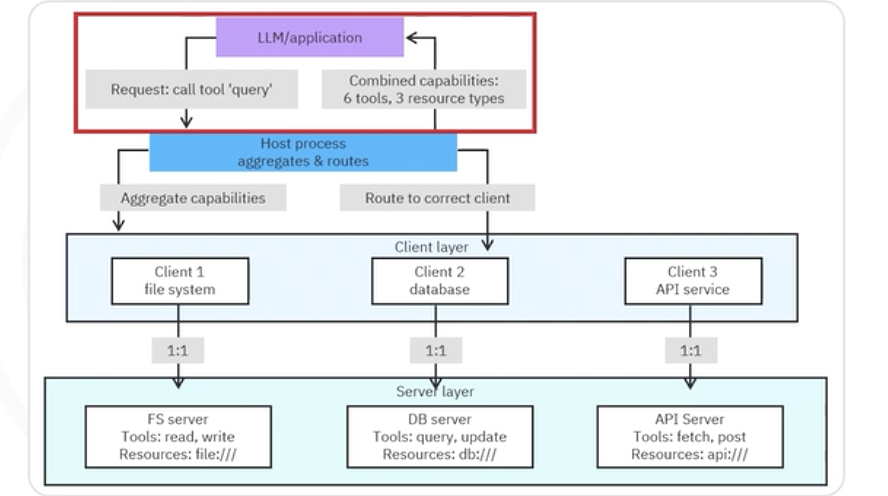

### TypeScritps vs Python SDKs
- 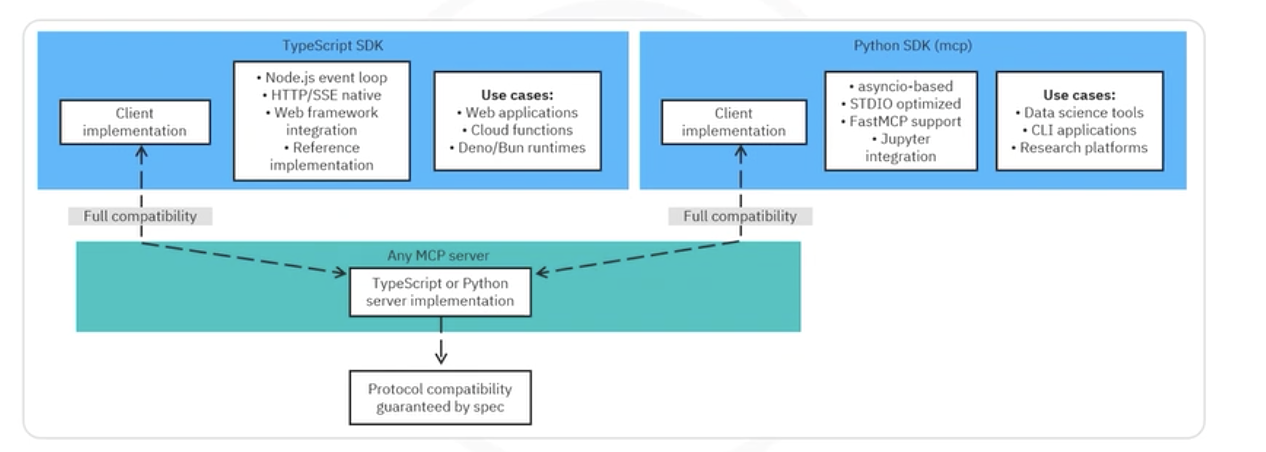
- both frameworks offers complete feature parity
- Python
    - uses asyncio
- both SDKs are cross compatable

### MCP Client testing and validation
- test servers are built into SDK
- verifz the initialiyation handshae completes with proper capability negotiation
    - 3 phases (initialization, operation and shutdown)
- Validate JSON-RPC message formatting
    - all request must have ides
    - notification must have not
- Veryfy transport layer: STDIO process management of HTTP connection handling
- Test error handling for malfrmed responses and timeouts
- Test capability detection
- Use the MCP Inspector for debugging
    - https://github.com/modelcontextprotocol/inspector

### Summary
- MCP defines a three-lazer architecture with 1:1 client to server connections
- JSON-RPC 2.0 proves the message foundation
- Everz connection has three phases: initialiyation, operation, and shutdown
- S>TDIO transport enables local development
- Multi-sever hosts aggregate capabilites and route requests
- Both TypeScript and Python SDKS are production-readz and fully compatible

### [Lab: Built a Custom MCP Client with Pyython](./Labs/Built%20a%20custom%20MCP%20Client%20with%20Python/)